# Working notebook for solving


In [1]:
%matplotlib inline

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import root

from constants import *
from zams_eos import *
from zams_opacity import *
from zams_energygeneration import *
from zams_gradients import *
from zams_structure_equations import *
from zams_initialboundaries import *
from zams_integrate import *

## Boundary check

In [2]:
P_c_guess = 2.5e17
T_c_guess = 1.5e7
L_star_guess = 1.6 * L_sun
R_star_guess = 16.0 * R_sun

# small mass near center
M_r_inner = m_inner

# boundary values
y_inner = load1(M_star, M_r_inner, P_c_guess, T_c_guess, X, Y, Z)
y_outer = load2(M_star, R_star_guess, L_star_guess, X, Y, Z)

print("Inner boundary [l, P, r, T] =", y_inner)
print("Outer boundary [l, P, r, T] =", y_outer)

# derivatives at the boundaries
#dy_inner = derivs(M_r_inner, y_inner, X, Y, Z)
#dy_outer = derivs(M_star, y_outer, X, Y, Z)

#print("Inner boundary derivatives [dl/dm, dP/dm, dr/dm, dT/dm] =", dy_inner)
#print("Outer boundary derivatives [dl/dm, dP/dm, dr/dm, dT/dm] =", dy_outer)

Inner boundary [l, P, r, T] = [np.float64(1.4051821801650052e+27), 2.4999609692006474e+17, 42393796.19370008, np.float64(14999906.469433714)]
Outer boundary [l, P, r, T] = [6.124800000000001e+33, 2861.4477191851765, 1113120000000.0, 1622.918028674558]


## Shooting Method for Solving

In [3]:
guess0 = np.array([
    np.log10(1.4e17),
    np.log10(2.0e7),    # right at the L crossover
    np.log10(16.4 * L_sun),
    np.log10(1.6 * R_sun),
])

sol_root = root(residuals, guess0, method="hybr", tol=1e-10,options={'factor': 0.001})
print(sol_root.success, sol_root.message)
print(sol_root.x)

True The solution converged.
[17.1761963   7.30490863 34.7231572  11.07607624]


In [4]:
Pc_sol = 10**sol_root.x[0]
Tc_sol = 10**sol_root.x[1]
Ls_sol = 10**sol_root.x[2]
Rs_sol = 10**sol_root.x[3]

print("Pc =", Pc_sol)
print("Tc =", Tc_sol)
print("L* =", Ls_sol)
print("R* =", Rs_sol)

Pc = 1.5003628491795658e+17
Tc = 20179417.702638514
L* = 5.286365715338471e+34
R* = 119145113700.1497


In [5]:
sol_out = integrate_outward(Pc_sol, Tc_sol, Ls_sol, Rs_sol)
sol_in  = integrate_inward(Pc_sol, Tc_sol, Ls_sol, Rs_sol)

In [6]:
m_out = sol_out.t
m_in  = sol_in.t[::-1]

y_out = sol_out.y
y_in  = sol_in.y[:, ::-1]

m_all = np.concatenate([m_out, m_in[1:]])
y_all = np.hstack([y_out, y_in[:, 1:]])

l_all = y_all[0]
P_all = y_all[1]
r_all = y_all[2]
T_all = y_all[3]

In [7]:
rho_all = []
eps_all = []
kappa_all = []
grad_ad_all = []
grad_all = []
transport_all = []

for m, l, P, r, T in zip(m_all, l_all, P_all, r_all, T_all):
    rho, beta = compute_density(P, T, X, Y, Z)
    kappa = get_opacity(T, rho)
    eps_pp, eps_cno, eps = nuclear_energy_rates(rho, T, X, Y)
    grad, grad_rad, grad_ad, transport = actual_nabla(l, P, T, m, kappa, beta)

    rho_all.append(rho)
    eps_all.append(eps)
    kappa_all.append(kappa)
    grad_ad_all.append(grad_ad)
    grad_all.append(grad)
    transport_all.append(transport)

In [8]:
print("Residuals at fitting point:", sol_root.fun)
print("Converged:", sol_root.success)

Residuals at fitting point: [ 1.13041771e-10  1.45338911e-08  1.12416670e-09 -2.60932975e-08]
Converged: True


In [9]:
print("Number of function evaluations:", sol_root.nfev)
print("Converged:", sol_root.success)
print("Message:", sol_root.message)

Number of function evaluations: 36
Converged: True
Message: The solution converged.


In [10]:
# Build full DataFrame in physical units
df_full = pd.DataFrame({
    'm': np.array(m_all) / M_sun,
    'r':np.array(r_all) / R_sun,
    'rho':rho_all,
    'T':T_all,
    'P':P_all,
    'l':np.array(l_all) / L_sun,
    'eps':eps_all,
    'kappa':kappa_all,
    'nabla_ad':grad_ad_all,
    'nabla':grad_all,
    'transport':transport_all,
})

m_min = df_full['m'].min()
m_max = df_full['m'].max()

# Find the exact mass where outer convection begins
outer_conv_mask = (df_full['transport'] == 'convective') & (df_full['m'] > 1.0)
m_conv_start = df_full[outer_conv_mask]['m'].min()

# Three-zone sampling + forced outer convection zone rows
n_log  = 17
n_lin  = 160
n_surf = 50

m_log  = np.logspace(np.log10(m_min), np.log10(0.1 * m_max), n_log, endpoint=False)
m_lin  = np.linspace(0.1 * m_max, m_conv_start * 0.999, n_lin, endpoint=False)
m_surf = np.linspace(m_conv_start, m_max, n_surf)
m_vals = np.concatenate([m_log, m_lin, m_surf])

idx = [np.argmin(np.abs(df_full['m'].values - m)) for m in m_vals]
df_sample = df_full.iloc[idx].drop_duplicates(subset='m').reset_index(drop=True)

#df_sample.to_csv('/Users/kmanj/mesa_work/structure_table.csv', index=False)
print(f"Saved {len(df_sample)} rows to structure_table.csv")
print("\nTransport zone counts:")
print(df_sample['transport'].value_counts())
print("\nOuter convective rows:")
print(df_sample[df_sample['transport'] == 'convective'][['m', 'r', 'T', 'rho']].tail(10).to_string())

Saved 121 rows to structure_table.csv

Transport zone counts:
transport
radiative     78
convective    43
Name: count, dtype: int64

Outer convective rows:
       m         r             T           rho
107  2.0  1.711139  13480.308119  6.020871e-09
108  2.0  1.711267  12995.530242  5.689942e-09
109  2.0  1.711390  12528.070315  5.377559e-09
110  2.0  1.711508  12077.321342  5.082650e-09
111  2.0  1.711623  11642.695174  4.804205e-09
112  2.0  1.711733  11223.626417  4.541278e-09
113  2.0  1.711839  10819.573566  4.292984e-09
114  2.0  1.711941  10429.972613  4.058465e-09
115  2.0  1.712039  10054.355418  3.836962e-09
116  2.0  1.712134   9692.410156  3.627837e-09


In [15]:
df_sample = df_full.iloc[idx].drop_duplicates(subset='m').reset_index(drop=True)

# Rename columns to match report conventions
df_table = df_sample.rename(columns={
    'm': 'm_Msun',
    'r': 'r_Rsun',
    'rho': 'rho_gcc',
    'T':'T_K',
    'P': 'P_dcm2',
    'l':'l_Lsun',
    'eps': 'eps_erggs',
    'kappa':'kappa_cm2g',
    'nabla_ad': 'nabla_ad',
    'nabla':'nabla',
    'transport':'transport',
})

#df_full.to_csv('stellar_structure_table.csv', index=False)
print(f"Saved {len(df_full)} rows to stellar_structure_table.csv")

Saved 611 rows to stellar_structure_table.csv


In [11]:
df_sample

,m,r,rho,T,P,l,eps,kappa,nabla_ad,nabla,transport
0,2.000000e-08,0.000798,5.547733e+01,2.017935e+07,1.500350e+17,0.000005,4.608948e+02,0.781302,0.396712,0.396712,convective
1,5.656363e-08,0.001129,5.547704e+01,2.017928e+07,1.500336e+17,0.000014,4.608654e+02,0.781305,0.396712,0.396712,convective
2,1.228658e-07,0.001462,5.547664e+01,2.017918e+07,1.500318e+17,0.000029,4.608257e+02,0.781309,0.396712,0.396712,convective
3,3.495702e-07,0.002071,5.547564e+01,2.017894e+07,1.500274e+17,0.000084,4.607266e+02,0.781319,0.396712,0.396712,convective
4,9.929536e-07,0.002933,5.547364e+01,2.017846e+07,1.500184e+17,0.000238,4.605280e+02,0.781338,0.396712,0.396712,convective
...,...,...,...,...,...,...,...,...,...,...,...
116,2.000000e+00,1.712134,3.627837e-09,9.692410e+03,4.721600e+03,13.809733,1.383154e-70,21.247382,0.394504,0.394504,convective
117,2.000000e+00,1.712261,3.351821e-09,9.207373e+03,4.142652e+03,13.809733,8.569568e-72,12.140089,0.394889,0.366628,radiative
118,2.000000e+00,1.712357,3.123334e-09,8.918560e+03,3.738765e+03,13.809733,1.456815e-72,8.521086,0.395011,0.263823,radiative
119,2.000000e+00,1.712440,2.909805e-09,8.734642e+03,3.411453e+03,13.809733,4.417132e-73,6.387221,0.394971,0.196128,radiative


## Plots

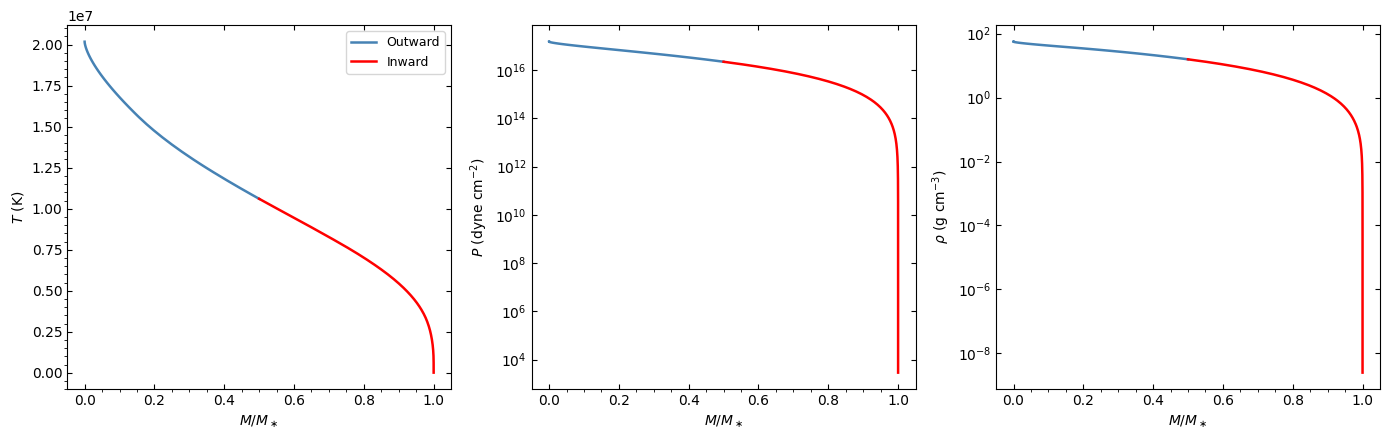

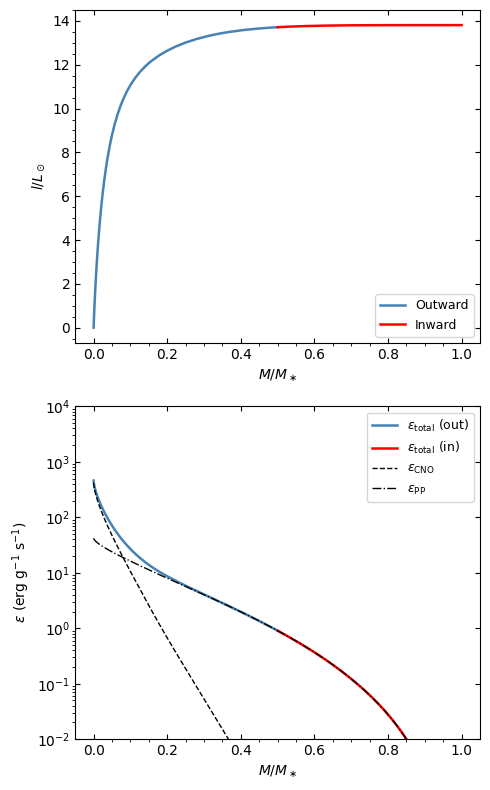

In [12]:

eps_pp_arr  = []
eps_cno_arr = []

for rho, T in zip(rho_all, T_all):
    eps_pp, eps_cno, eps_tot = nuclear_energy_rates(rho, T, X, Y)
    eps_pp_arr.append(eps_pp)
    eps_cno_arr.append(eps_cno)

eps_pp_arr  = np.array(eps_pp_arr)
eps_cno_arr = np.array(eps_cno_arr)

rho_all    = np.array(rho_all)
eps_all    = np.array(eps_all)
grad_all   = np.array(grad_all)
grad_ad_all = np.array(grad_ad_all)

n_out = len(sol_out.t)
q = m_all / M_star

# Color scheme
c_out = 'steelblue'
c_in  = 'red'  
lw = 1.8

def plot_split(ax, y, log=False):
    plot_fn = ax.semilogy if log else ax.plot
    ax.plot(q[:n_out],  y[:n_out],  color=c_out, lw=lw, label='Outward')
    plot_fn(q[n_out-1:], y[n_out-1:], color=c_in,  lw=lw, label='Inward')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plt.subplots_adjust(wspace=0.35)

plot_split(axes[0], T_all)
axes[0].set_xlabel(r"$M/M_\ast$")
axes[0].set_ylabel(r"$T\ ({\rm K})$")
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].minorticks_on()
axes[0].legend(fontsize=9)

plot_split(axes[1], P_all, log=True)
axes[1].set_xlabel(r"$M/M_\ast$")
axes[1].set_ylabel(r"$P\ ({\rm dyne\ cm^{-2}})$")
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].minorticks_on()

plot_split(axes[2], rho_all, log=True)
axes[2].set_xlabel(r"$M/M_\ast$")
axes[2].set_ylabel(r"$\rho\ ({\rm g\ cm^{-3}})$")
axes[2].tick_params(direction='in', top=True, right=True)
axes[2].minorticks_on()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(5, 8))

axes[0].plot(q[:n_out],   np.array(l_all[:n_out]) / L_sun,   color=c_out, lw=lw, label='Outward')
axes[0].plot(q[n_out-1:], np.array(l_all[n_out-1:]) / L_sun, color=c_in,  lw=lw, label='Inward')
axes[0].set_xlabel(r"$M/M_\ast$")
axes[0].set_ylabel(r"$l/L_\odot$")
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].minorticks_on()
axes[0].legend(fontsize=9)

axes[1].semilogy(q[:n_out], eps_all[:n_out],   color=c_out,   lw=lw, label=r'$\epsilon_\mathrm{total}$ (out)')
axes[1].semilogy(q[n_out-1:], eps_all[n_out-1:], color=c_in,    lw=lw,label=r'$\epsilon_\mathrm{total}$ (in)')
axes[1].semilogy(q, eps_cno_arr, color='black', lw=1, linestyle='--', label=r'$\epsilon_\mathrm{CNO}$')
axes[1].semilogy(q,eps_pp_arr,color='black', lw=1, linestyle='-.', label=r'$\epsilon_\mathrm{PP}$')
axes[1].set_xlabel(r"$M/M_\ast$")
axes[1].set_ylabel(r"$\epsilon\ ({\rm erg\ g^{-1}\ s^{-1}})$")
axes[1].set_ylim(1e-2, 1e4)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].minorticks_on()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

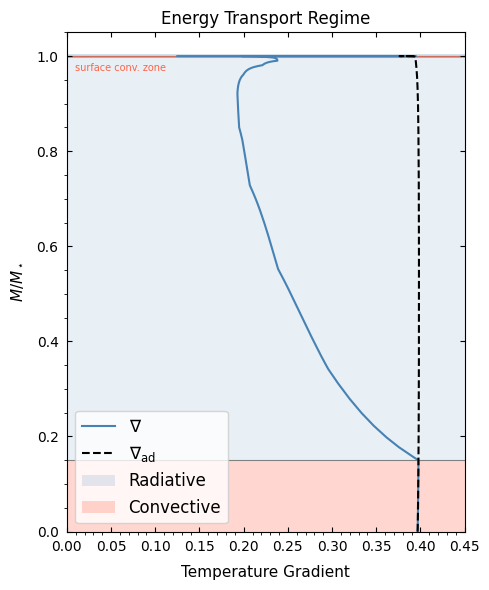

In [13]:
q = np.array(m_all) / np.array(m_all).max()
nabla = np.array(grad_all)
nabla_ad  = np.array(grad_ad_all)
transport_arr = np.array(transport_all)

conv_mask = transport_arr == 'convective'
rad_mask  = transport_arr == 'radiative'

def get_regions_q(mask, q):
    regions = []
    in_region = False
    for i, val in enumerate(mask):
        if val and not in_region:
            start = q[i-1] + 0.5*(q[i]-q[i-1]) if i > 0 else q[i]
            in_region = True
        elif not val and in_region:
            end = q[i-1] + 0.5*(q[i]-q[i-1])
            regions.append((start, end))
            in_region = False
    if in_region:
        regions.append((start, 1.0))
    return regions

fig, ax = plt.subplots(figsize=(5, 6))

for q0, q1 in get_regions_q(rad_mask, q):
    ax.axhspan(q0, q1+0.005, color='steelblue', alpha=0.12, lw=0, zorder=0)

for q0, q1 in get_regions_q(conv_mask, q):
    ax.axhspan(q0, q1, color='tomato', alpha=0.25, lw=0, zorder=0)

transitions = np.where(np.diff(conv_mask.astype(int)) != 0)[0]
for t in transitions:
    ax.axhline(q[t] + 0.5*(q[t+1]-q[t]), color='gray', lw=0.8, zorder=1)

# surface convective shell marker
ax.axhline(0.9984, color='tomato', lw=1.5, alpha=0.6, zorder=1)
ax.annotate('surface conv. zone', xy=(0.02, 0.965),xycoords=('axes fraction', 'data'),va='bottom', ha='left', fontsize=7, color='tomato')

ax.plot(nabla, q, color='steelblue', lw=1.5, label=r'$\nabla$', zorder=2)
ax.plot(nabla_ad, q, color='black', linestyle='--', lw=1.5,label=r'$\nabla_{\rm ad}$', zorder=2)

ax.tick_params(direction='in', top=True, right=True, pad=6)
ax.set_xlabel('Temperature Gradient', labelpad=8, fontsize = 11)
ax.set_ylabel(r'$M/M_\star$', labelpad=8, fontsize = 11)
ax.set_title('Energy Transport Regime', fontsize = 12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 0.45)
ax.tick_params(direction='in', top=True, right=True)
ax.minorticks_on()

handles = [
    plt.Line2D([], [], color='steelblue', lw=1.5, label=r'$\nabla$'),
    plt.Line2D([], [], color='black', linestyle='--', lw=1.5, label=r'$\nabla_{\rm ad}$'),
    Patch(facecolor='steelblue', alpha=0.15, label='Radiative'),
    Patch(facecolor='tomato',    alpha=0.25, label='Convective'),
]
ax.legend(handles=handles, loc='lower left', fontsize = 12)
plt.tight_layout()
plt.show()